<a href="https://colab.research.google.com/github/Sujal-Sharma-Codes/Prodigy-GA-4real/blob/main/pix2pix_image_translation_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-04: Image-to-Image Translation with Pix2Pix (cGAN)
Implement Pix2Pix — a conditional GAN that translates an input image into a corresponding output image (building facade labels -> real facade photos).

**Before running:** Runtime -> Change runtime type -> T4 GPU. Then Runtime -> Run all.

## 1. Install libraries

In [1]:
!pip -q install torch torchvision

## 2. Download the dataset
CMP Facades dataset (paired label/photo images, ~30 MB) from the original Pix2Pix paper.

In [2]:
import os, urllib.request, tarfile

url = "http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz"
tar_path = "facades.tar.gz"

if not os.path.exists("facades"):
    urllib.request.urlretrieve(url, tar_path)
    with tarfile.open(tar_path) as t:
        t.extractall(".")

print("Train images:", len(os.listdir("facades/train")))
print("Val images:", len(os.listdir("facades/val")))

/tmp/ipykernel_1373/303182631.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(".")


Train images: 400
Val images: 100


## 3. Dataset class
Each file is a side-by-side pair: left half = target photo, right half = input label map.

In [3]:
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

IMG_SIZE = 256

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5] * 3, [0.5] * 3),
])

class FacadesDataset(Dataset):
    def __init__(self, root):
        self.files = sorted(glob.glob(os.path.join(root, "*.jpg")))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        w, h = img.size
        photo = img.crop((0, 0, w // 2, h))
        label = img.crop((w // 2, 0, w, h))
        return transform(label), transform(photo)  # (input, target)

train_ds = FacadesDataset("facades/train")
val_ds = FacadesDataset("facades/val")
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=True, drop_last=True)

print("Train pairs:", len(train_ds), "| Val pairs:", len(val_ds))

Train pairs: 400 | Val pairs: 100


## 4. Generator (U-Net) and Discriminator (PatchGAN)

In [4]:
import torch.nn as nn

class UNetDown(nn.Module):
    def __init__(self, in_c, out_c, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
                  nn.InstanceNorm2d(out_c), nn.ReLU()]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x, skip):
        x = self.model(x)
        return torch.cat([x, skip], dim=1)

class GeneratorUNet(nn.Module):
    def __init__(self, in_c=3, out_c=3):
        super().__init__()
        self.d1 = UNetDown(in_c, 64, normalize=False)
        self.d2 = UNetDown(64, 128)
        self.d3 = UNetDown(128, 256)
        self.d4 = UNetDown(256, 512, dropout=0.5)
        self.d5 = UNetDown(512, 512, dropout=0.5)
        self.d6 = UNetDown(512, 512, dropout=0.5)
        self.d7 = UNetDown(512, 512, dropout=0.5)
        self.d8 = UNetDown(512, 512, normalize=False, dropout=0.5)

        self.u1 = UNetUp(512, 512, dropout=0.5)
        self.u2 = UNetUp(1024, 512, dropout=0.5)
        self.u3 = UNetUp(1024, 512, dropout=0.5)
        self.u4 = UNetUp(1024, 512, dropout=0.5)
        self.u5 = UNetUp(1024, 256)
        self.u6 = UNetUp(512, 128)
        self.u7 = UNetUp(256, 64)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_c, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        d1 = self.d1(x); d2 = self.d2(d1); d3 = self.d3(d2); d4 = self.d4(d3)
        d5 = self.d5(d4); d6 = self.d6(d5); d7 = self.d7(d6); d8 = self.d8(d7)
        u1 = self.u1(d8, d7); u2 = self.u2(u1, d6); u3 = self.u3(u2, d5)
        u4 = self.u4(u3, d4); u5 = self.u5(u4, d3); u6 = self.u6(u5, d2)
        u7 = self.u7(u6, d1)
        return self.final(u7)

class Discriminator(nn.Module):
    def __init__(self, in_c=3):
        super().__init__()
        def block(ic, oc, normalize=True):
            layers = [nn.Conv2d(ic, oc, 4, 2, 1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(oc))
            layers.append(nn.LeakyReLU(0.2))
            return layers
        self.model = nn.Sequential(
            *block(in_c * 2, 64, normalize=False),
            *block(64, 128),
            *block(128, 256),
            *block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1, bias=False),
        )

    def forward(self, img_input, img_target):
        x = torch.cat([img_input, img_target], dim=1)
        return self.model(x)

## 5. Setup
The discriminator's exact output shape is measured directly with a dummy forward pass, so the real/fake label tensors always match its actual size — no hand calculation, no shape-mismatch errors.

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

G_model = GeneratorUNet().to(device)
D_model = Discriminator().to(device)

criterion_gan = nn.MSELoss()
criterion_l1 = nn.L1Loss()
lambda_l1 = 100

opt_G = torch.optim.Adam(G_model.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D_model.parameters(), lr=2e-4, betas=(0.5, 0.999))

G_model.eval(); D_model.eval()
with torch.no_grad():
    _dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    patch_shape = D_model(_dummy, _dummy).shape[1:]
G_model.train(); D_model.train()

print("Discriminator output shape per sample:", patch_shape)

Device: cuda
Discriminator output shape per sample: torch.Size([1, 16, 16])


## 6. Training loop
20 epochs on ~400 pairs takes roughly 15-25 minutes on a T4. A sample image grid is saved every 5 epochs.

In [6]:
import time
from torchvision.utils import make_grid, save_image

n_epochs = 20
os.makedirs("outputs", exist_ok=True)

def sample_and_show(epoch):
    G_model.eval()
    inp, tgt = next(iter(val_loader))
    inp, tgt = inp.to(device), tgt.to(device)
    with torch.no_grad():
        fake = G_model(inp)
    grid = torch.cat([inp[:3], fake[:3], tgt[:3]], dim=0)
    grid = (grid * 0.5 + 0.5).clamp(0, 1)
    save_image(make_grid(grid, nrow=3), f"outputs/epoch_{epoch}.png")
    G_model.train()

for epoch in range(1, n_epochs + 1):
    start = time.time()
    for inp, tgt in train_loader:
        inp, tgt = inp.to(device), tgt.to(device)
        bs = inp.size(0)
        valid = torch.ones((bs, *patch_shape), device=device)
        fake_lbl = torch.zeros((bs, *patch_shape), device=device)

        # ---- generator ----
        opt_G.zero_grad()
        fake = G_model(inp)
        pred_fake = D_model(inp, fake)
        loss_gan = criterion_gan(pred_fake, valid)
        loss_l1 = criterion_l1(fake, tgt)
        loss_G = loss_gan + lambda_l1 * loss_l1
        loss_G.backward()
        opt_G.step()

        # ---- discriminator ----
        opt_D.zero_grad()
        pred_real = D_model(inp, tgt)
        loss_real = criterion_gan(pred_real, valid)
        pred_fake = D_model(inp, fake.detach())
        loss_fake = criterion_gan(pred_fake, fake_lbl)
        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        opt_D.step()

    print(f"Epoch {epoch}/{n_epochs}  G_loss={loss_G.item():.3f}  D_loss={loss_D.item():.3f}  ({time.time()-start:.0f}s)")
    if epoch % 5 == 0 or epoch == n_epochs:
        sample_and_show(epoch)

print("Training complete.")

Epoch 1/20  G_loss=39.097  D_loss=0.130  (13s)
Epoch 2/20  G_loss=34.740  D_loss=0.059  (12s)
Epoch 3/20  G_loss=36.599  D_loss=0.024  (13s)
Epoch 4/20  G_loss=35.134  D_loss=0.023  (13s)
Epoch 5/20  G_loss=36.690  D_loss=0.062  (13s)
Epoch 6/20  G_loss=34.830  D_loss=0.029  (13s)
Epoch 7/20  G_loss=39.405  D_loss=0.076  (14s)
Epoch 8/20  G_loss=31.267  D_loss=0.050  (14s)
Epoch 9/20  G_loss=33.994  D_loss=0.242  (14s)
Epoch 10/20  G_loss=29.810  D_loss=0.030  (14s)
Epoch 11/20  G_loss=33.400  D_loss=0.035  (14s)
Epoch 12/20  G_loss=31.547  D_loss=0.070  (14s)
Epoch 13/20  G_loss=32.641  D_loss=0.031  (14s)
Epoch 14/20  G_loss=31.863  D_loss=0.018  (14s)
Epoch 15/20  G_loss=30.268  D_loss=0.063  (14s)
Epoch 16/20  G_loss=29.269  D_loss=0.060  (14s)
Epoch 17/20  G_loss=31.527  D_loss=0.040  (14s)
Epoch 18/20  G_loss=31.909  D_loss=0.073  (14s)
Epoch 19/20  G_loss=32.008  D_loss=0.025  (14s)
Epoch 20/20  G_loss=28.879  D_loss=0.015  (14s)
Training complete.


## 7. View results
Each grid shows, left to right: **input label map -> generated photo -> real photo**.

outputs/epoch_5.png


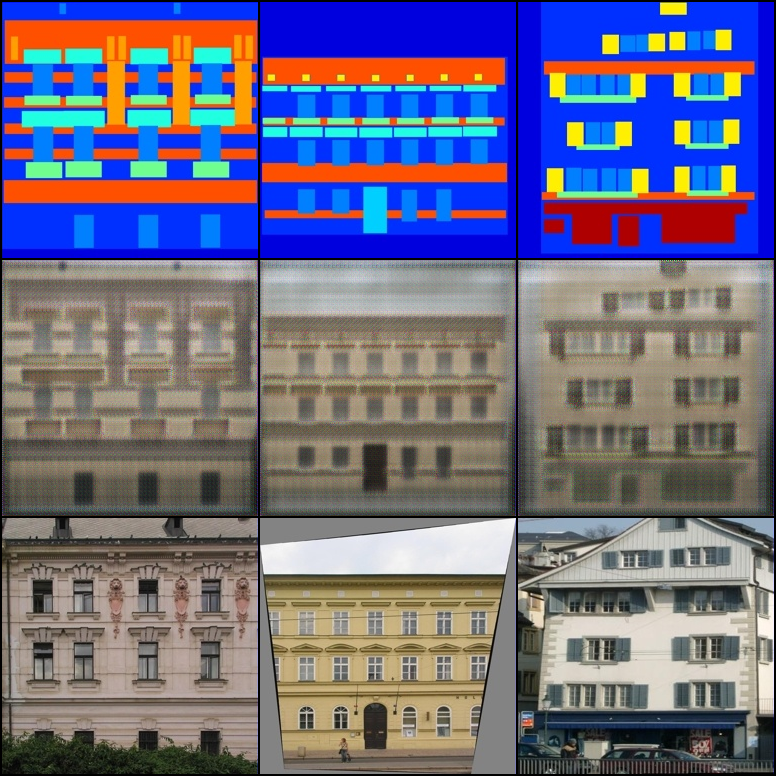

outputs/epoch_10.png


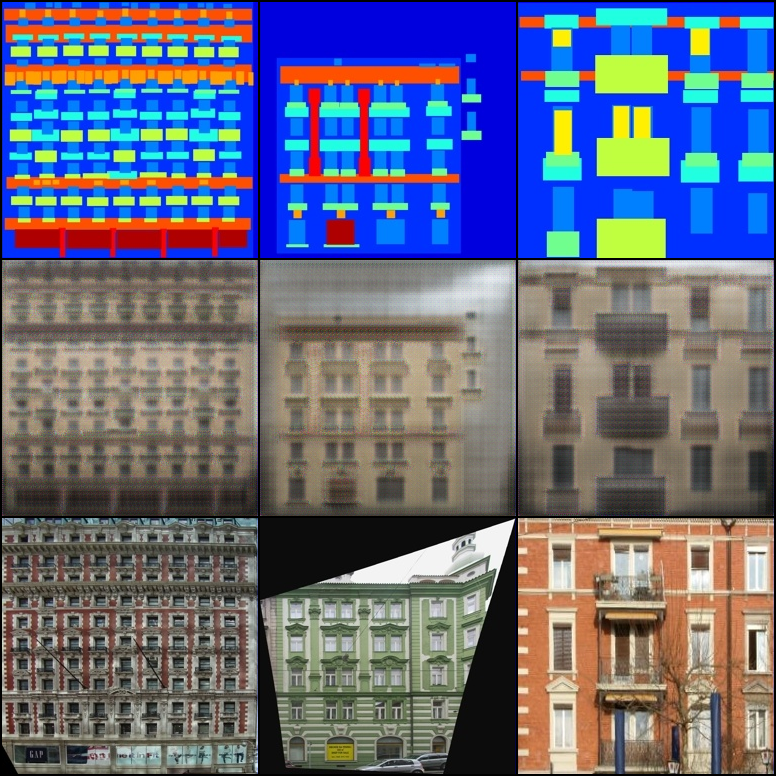

outputs/epoch_15.png


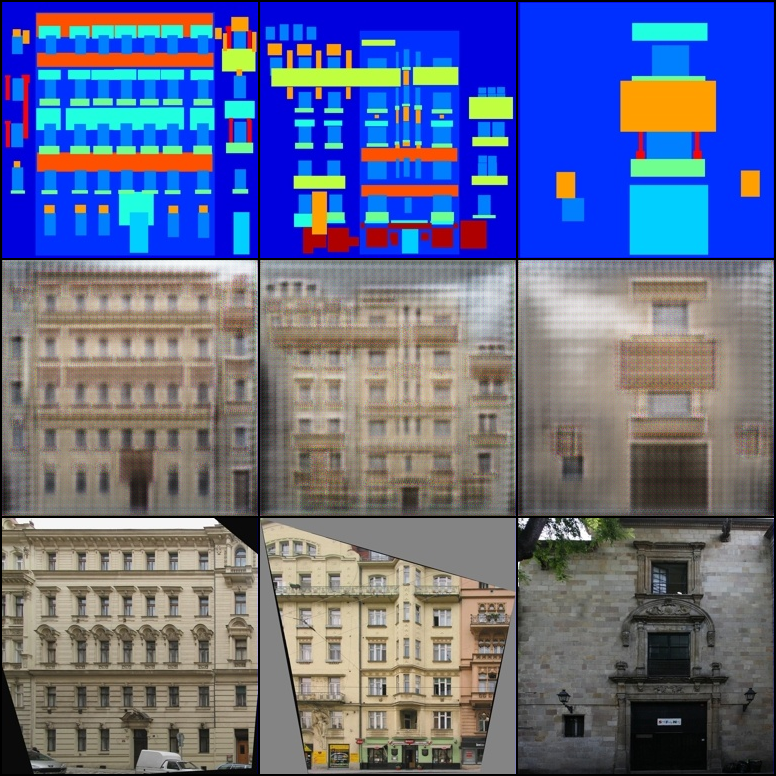

outputs/epoch_20.png


In [7]:
from IPython.display import display, Image as IPImage
import glob as g

for f in sorted(g.glob("outputs/epoch_*.png"), key=lambda p: int(p.split("_")[-1].split(".")[0])):
    print(f)
    display(IPImage(f))

## 8. Save the trained generator

In [ ]:
torch.save(G_model.state_dict(), "pix2pix_generator.pth")
print("Saved pix2pix_generator.pth")

## 9. Notes
- **Dataset:** CMP Facades (400 train / 100 val paired images of building facade label maps and real photos).
- To translate a different image pair (sketches -> photos, maps -> satellite), swap the dataset and keep the same input/target split logic.
- Pix2Pix needs **paired** data. For unpaired image sets, CycleGAN is the standard alternative.